In [1]:
# ==============================================================================
# CELL 1: SETUP & IMPORTS
# ==============================================================================
import sys
from pathlib import Path
import pandas as pd

import plotly.io as pio
# Se estiver no JupyterLab:
pio.renderers.default = "jupyterlab"
# (alternativas: "notebook_connected" no Jupyter clássico, ou "colab" no Colab)


# --- Setup Project Path ---
# This ensures all imports from your 'src' directory work correctly.
project_root = Path.cwd().parent.parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# --- Import Your Analysis Toolkit ---
from hpo.analysis import (
    analyze_single_campaign, 
    aggregate_all_campaign_results, 
    analyze_across_campaigns,
    run_validation_analysis,
    analyze_holistically,
    analyze_best_per_architecture
)
from config_loader import load_campaign_config

# --- Jupyter Extensions ---
%load_ext autoreload
%autoreload 2
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)

In [2]:
# ==============================================================================
# GLOBAL CONFIGURATION (The Only Cell You Edit)
# ==============================================================================
# Define the root directory for all experiment results.
RESULTS_DIR = project_root / "src" / "experiment_configs" / "results"
CONFIGS_DIR = project_root / "src" / "experiment_configs" / "hpo_campaigns"

# Define the scoring logic here ---
METRIC_WEIGHTS = {
    'val_smape_cum': 2.0,
    'val_smape_agg': 2.0
}
LOWER_IS_BETTER = {
    'val_smape_cum': True,
    'val_smape_agg': True
}
METRIC_TO_OPTIMIZE = "weighted_score"

# ==============================================================================
# DATA AGGREGATION (Run this once to load all data)
# ==============================================================================
# This function scans all your result folders and builds the master DataFrame.
master_df = aggregate_all_campaign_results(
    results_dir=RESULTS_DIR,
    metric_weights=METRIC_WEIGHTS,
    lower_is_better=LOWER_IS_BETTER
)

if master_df is not None and not master_df.empty:
    analyze_holistically(master_df, metric_to_optimize=METRIC_TO_OPTIMIZE, n_top_per_well=2)
    analyze_best_per_architecture(master_df, metric_to_optimize=METRIC_TO_OPTIMIZE)
else:
    print("Master DataFrame is empty. Run some campaigns first.")

Discovered 10 unique campaigns to aggregate.
⚠️ WARNING: No leaderboards found for campaign '.ipynb_checkpoints' in '/home/gabriel/Documentos/Equinor/src/experiment_configs/results'. Searched for both HPO and validation patterns.
✅ Aggregated 3 leaderboard(s) for campaign 'VOLVE_15-9-F-12_Seq2Context' with 9 total trials.
✅ Aggregated 3 leaderboard(s) for campaign 'VOLVE_15-9-F-12_Seq2PIN' with 9 total trials.
✅ Aggregated 3 leaderboard(s) for campaign 'VOLVE_15-9-F-12_Seq2Trend' with 9 total trials.
✅ Aggregated 3 leaderboard(s) for campaign 'VOLVE_15-9-F-14_Seq2Context' with 9 total trials.
✅ Aggregated 3 leaderboard(s) for campaign 'VOLVE_15-9-F-14_Seq2PIN' with 9 total trials.
✅ Aggregated 3 leaderboard(s) for campaign 'VOLVE_15-9-F-14_Seq2Trend' with 9 total trials.
✅ Loaded 1 leaderboard(s) for campaign 'validation_VOLVE_15-9-F-14_Seq2Context' with 6 total trials.
✅ Loaded 1 leaderboard(s) for campaign 'validation_VOLVE_15-9-F-14_Seq2Context_top_3' with 9 total trials.
✅ Loaded 1

,well,architecture,weighted_score,val_smape_agg,val_smape_cum,architecture_profile,physics_strategy,epochs,data_sample,learning_rate,lag_window,batch_size,group
25,15-9-F-12,Seq2Trend,0.8205,25.663766,0.0700,N/A,combined_exp_arps,200,0.900000,0.008046,30,32,0
19,15-9-F-12,Seq2Trend,0.8718,26.043194,0.0609,N/A,pressure_ensemble,50,0.900000,0.000454,30,32,0
73,15-9-F-14,Seq2Trend,0.4359,16.837819,0.0750,N/A,exponential,20,0.750000,0.000109,30,64,1
53,15-9-F-14,Seq2Trend,0.5641,17.258659,0.1185,N/A,arps,50,0.500000,0.000166,30,16,1



--- 🏛️ Average 'Best Score' by Architecture ---
              mean  std  count
architecture                  
Seq2Trend     0.61 0.20      3
Seq2Context   1.08 0.43      4
Seq2PIN       1.73 1.25      2

--- 🛢️ Winning Architecture per Well ---
          architecture  weighted_score
well                                  
15-9-F-12    Seq2Trend          0.8205
15-9-F-14    Seq2Trend          0.4359

==================== ✅ Holistic Analysis Complete ====================

==================== 🏆 Architecture Champions League 🏆 ====================
Showing the single best trial for each architecture, grouped by well.


,well,architecture,weighted_score,val_smape_cum,val_smape_agg,architecture_profile,physics_strategy,data_sample,learning_rate,lag_window,batch_size,group
25,15-9-F-12,Seq2Trend,0.8205,0.0700,25.663766,N/A,combined_exp_arps,0.900000,0.008046,30,32,0
6,15-9-F-12,Seq2Context,1.7179,0.3705,26.231922,arch_tcn_04_concat,combined_exp_arps,0.250000,0.007161,7,32,0
13,15-9-F-12,Seq2PIN,2.6154,1.2094,39.649558,N/A,combined_exp_arps,0.250000,0.000838,30,64,0
73,15-9-F-14,Seq2Trend,0.4359,0.0750,16.837819,N/A,exponential,0.750000,0.000109,30,64,1
63,15-9-F-14,Seq2Context,0.7949,0.2436,18.968542,arch_cnn_03_film,arps,0.250000,0.000100,15,32,1
39,15-9-F-14,Seq2PIN,0.8462,0.1441,20.219810,N/A,arps,0.250000,0.001739,30,16,1



==================== ✅ Architecture Comparison Complete ====================


📈 Model Performance Overview

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                           📊 Performance Distribution by Architecture (lower is better)

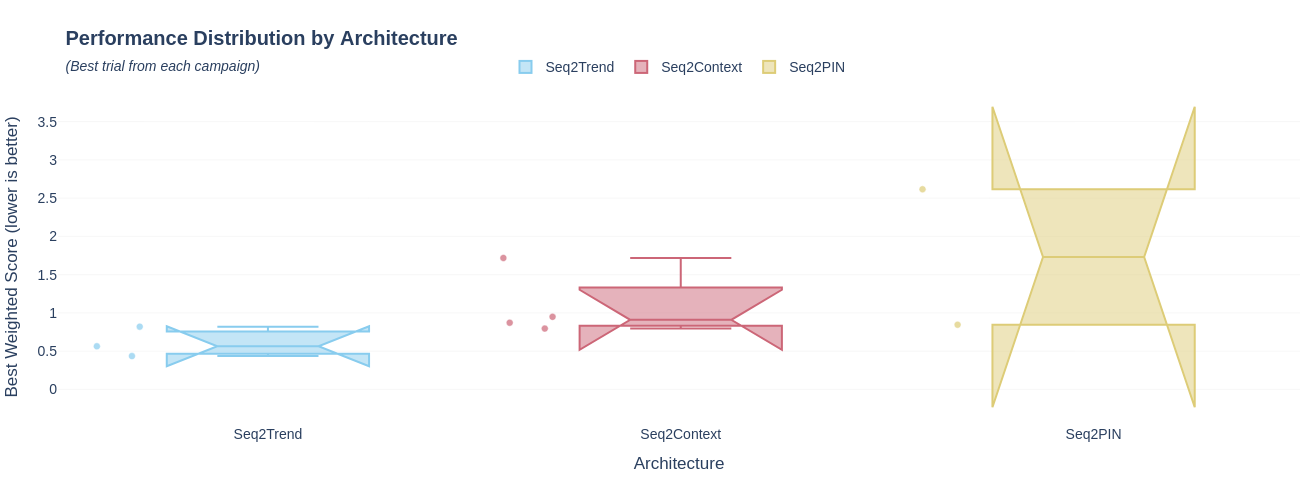

Interpretation: Each box summarizes the distribution of best-per-campaign scores for an architecture.              

 • A lower box indicates better overall performance (remember: lower is better).                                   
 • A shorter box shows more consistency across campaigns.                                                          
 • Points are the best scores from individual campaigns.

✅ Rendered **Performance Distribution by Architecture**.

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                     🥇 Best Architecture Performance per Well

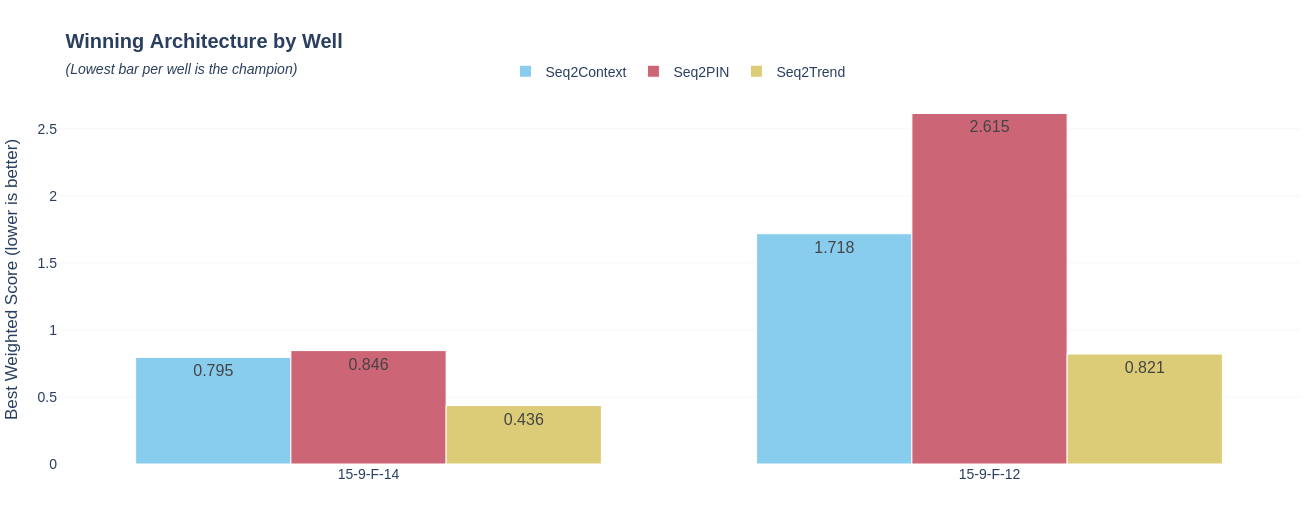

Interpretation: Head-to-head comparison of architectures on each well.                                             

 • For each well, the lowest bar is the current champion (best score).                                             
 • Use the sort order (best wells on the left) to quickly spot where models perform strongest or need attention.

✅ Rendered **Best Architecture Performance per Well**.

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

                                       🔎 Per-Well Hyperparameter Deep Dive

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                       🔬 Per-Well Hyperparameter Importance

Interpretation: This chart shows which hyperparameters have the strongest statistical relationship with top        
performance for each well.                                                                                         

 • A longer bar indicates a stronger association for that well's performance.                                      
 • Use this to focus tuning. If learning_rate is consistently important, fine-tune it; if batch_size is not, set a 
   sensible default.

✅ Rendered **Per-Well Hyperparameter Importance**.

In [3]:
# ==============================================================================
# ANALYSIS & VISUALIZATION
# ==============================================================================
# This script generates various plots to analyze architecture performance
# and per-well hyperparameter importance.

from hpo.analysis import (
    plot_performance_by_architecture,
    plot_champions_per_well,
    plot_hyperparameter_importance_per_well,
)

def generate_plots(master_df, metric_to_optimize):
    """
    Generate performance and hyperparameter importance plots
    if the DataFrame is non-empty.
    """
    if master_df is None or master_df.empty:
        print("Master DataFrame is empty. Cannot generate plots.")
        return

    # ------------------------------------------------------
    # 1. Architecture Performance Analysis
    # ------------------------------------------------------
    # Compare architectures in terms of performance consistency
    plot_performance_by_architecture(master_df, metric=metric_to_optimize)

    # Visual breakdown of the "Champions League" table
    plot_champions_per_well(master_df, metric=metric_to_optimize)

    # ------------------------------------------------------
    # 2. Per-Well Hyperparameter Deep Dive
    # ------------------------------------------------------
    # Identify which hyperparameters are most influential for each well
    plot_hyperparameter_importance_per_well(
        master_df, metric_col=metric_to_optimize
    )

generate_plots(master_df, METRIC_TO_OPTIMIZE)